## Modelling voor klachten train set
### Notebook Modelling klachten classificatie voor correcte expertise

### Inhoud

1. [Inleiding](#modelling-voor-klachten-train-set)
2. [Preprocessing](#preprocessing)
3. [Modellen](#modellen)
    - [Logistic Regression](#logistic-regression)
    - [Naive Bayes](#naive-bayes)
    - [Random Forest](#random-forest)
    - [SVC](#svc)
    - [SVC Calibrated Linear](#svc-calibrated-linear)
    - [SVC Calibrated Logistic](#svc-calibrated-logistic)
    - [Confusion Matrix](#confusion-matrix)

In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import uniform, randint
from imblearn.pipeline import Pipeline
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.svm import LinearSVC
from scipy.sparse import hstack
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.validation import check_is_fitted
from scipy.sparse import issparse
from sklearn.exceptions import NotFittedError



In [8]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Preprocessing

In [9]:
#preprocessing
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

train = pd.read_csv("klacht_train.csv")
test = pd.read_csv("klacht_test.csv")

train['Omschrijving_Cleaned'] = train['Omschrijving'].apply(preprocess_text)
test['Omschrijving_Cleaned'] = test['Omschrijving'].apply(preprocess_text)

y_train = train['Product']
y_test = test['Product']
x_train = train['Omschrijving_Cleaned']
x_test = test['Omschrijving_Cleaned']

In [10]:
print(len(train))
print(len(test))

9527
2382


### Modellen

#### Gridsearch

In [11]:
def run_search(pipeline, parameter_grid, name):
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=parameter_grid,
        cv=5,
        scoring='precision_macro',
        n_jobs=6,
        verbose=2
    )

    grid_search.fit(train['Omschrijving_Cleaned'], y_train)

    print(f"GridSearch {name} - beste parameters:")
    print(grid_search.best_params_)

    print("\nClassification report:")
    print(classification_report(
        y_test,
        grid_search.predict(test['Omschrijving_Cleaned'])
    ))

    return grid_search.best_estimator_

#### Logistic regression

In [12]:
#lr
lr_pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=5000, solver='lbfgs')) #(clf is classifier)
])

lr_parameters = {
    'vect': [TfidfVectorizer(), CountVectorizer()],
    'vect__ngram_range': [(1,1), (1,2)],
    'vect__max_features': [3000, 6000, 9000, 12000],
    'clf__C': [0.1, 1, 5, 10],
    'clf__penalty': ['l2'],
    'clf__class_weight': [None, 'balanced']
}

lr_best = run_search(lr_pipeline, lr_parameters, "Logistic Regression")

Fitting 5 folds for each of 128 candidates, totalling 640 fits
GridSearch Logistic Regression - beste parameters:
{'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l2', 'vect': TfidfVectorizer(), 'vect__max_features': 6000, 'vect__ngram_range': (1, 2)}

Classification report:
                    precision    recall  f1-score   support

      Bankrekening       0.86      0.84      0.85       240
Consumentenkrediet       0.88      0.54      0.67       156
        Creditcard       0.82      0.79      0.81       299
         Hypotheek       0.92      0.94      0.93       567
           Incasso       0.82      0.90      0.86       616
Kredietregistratie       0.84      0.85      0.84       504

          accuracy                           0.85      2382
         macro avg       0.86      0.81      0.83      2382
      weighted avg       0.86      0.85      0.85      2382



#### Naive Bayes

In [13]:
#nb
nb_pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

nb_parameters = {
    'vect': [TfidfVectorizer(), CountVectorizer()],
    'vect__ngram_range': [(1,1), (1,2)],
    'vect__max_features': [3000, 6000, 9000, 12000],
    'clf__alpha': [0.1, 0.5, 1.0],
}

nb_best = run_search(nb_pipeline, nb_parameters, "Naive Bayes")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
GridSearch Naive Bayes - beste parameters:
{'clf__alpha': 0.5, 'vect': TfidfVectorizer(), 'vect__max_features': 9000, 'vect__ngram_range': (1, 2)}

Classification report:
                    precision    recall  f1-score   support

      Bankrekening       0.88      0.80      0.84       240
Consumentenkrediet       0.92      0.31      0.47       156
        Creditcard       0.82      0.73      0.77       299
         Hypotheek       0.84      0.95      0.89       567
           Incasso       0.82      0.88      0.85       616
Kredietregistratie       0.79      0.85      0.82       504

          accuracy                           0.82      2382
         macro avg       0.84      0.75      0.77      2382
      weighted avg       0.83      0.82      0.82      2382



#### Random Forest

In [14]:
#rf
rf_pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_parameters = {
    'vect': [TfidfVectorizer()],
    'vect__ngram_range': [(1,1), (1,2)],
    'vect__max_features': [5000, 10000],
    'clf__n_estimators': [200, 400, 800],
    'clf__max_depth': [None, 10, 20, 40],
    'clf__min_samples_split': [2, 5, 10],
    'clf__class_weight': [None, 'balanced']
}

rf_best = run_search(rf_pipeline, rf_parameters, "Random Forest")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
GridSearch Random Forest - beste parameters:
{'clf__class_weight': None, 'clf__max_depth': 20, 'clf__min_samples_split': 10, 'clf__n_estimators': 800, 'vect': TfidfVectorizer(), 'vect__max_features': 10000, 'vect__ngram_range': (1, 1)}

Classification report:
                    precision    recall  f1-score   support

      Bankrekening       0.92      0.71      0.80       240
Consumentenkrediet       1.00      0.09      0.16       156
        Creditcard       0.89      0.56      0.69       299
         Hypotheek       0.82      0.94      0.87       567
           Incasso       0.68      0.91      0.78       616
Kredietregistratie       0.78      0.81      0.79       504

          accuracy                           0.78      2382
         macro avg       0.85      0.67      0.68      2382
      weighted avg       0.81      0.78      0.76      2382



### SVC

In [15]:
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
cw_dict = {cls: w for cls, w in zip(classes, cw)}

In [16]:
# vectorizers
char_vect = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=5, max_features=100_000)
word_vect = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=3, max_features=80_000,
                            sublinear_tf=True, stop_words="english")

In [17]:
# fitting vectorizer op traindata, transformatie train en test
Xtr_char = char_vect.fit_transform(x_train)
Xte_char = char_vect.transform(x_test)

Xtr = hstack([Xtr_char]).tocsr()
Xte = hstack([Xte_char]).tocsr()

In [18]:
# linearSVC
svc = LinearSVC(C=1.0, class_weight=cw_dict)
svc.fit(Xtr, y_train)
svc_pred = svc.predict(Xte)

print("\nLinearSVC")
print(classification_report(y_test, svc_pred, digits=2))


LinearSVC
                    precision    recall  f1-score   support

      Bankrekening       0.84      0.85      0.85       240
Consumentenkrediet       0.77      0.65      0.71       156
        Creditcard       0.79      0.82      0.80       299
         Hypotheek       0.92      0.94      0.93       567
           Incasso       0.84      0.87      0.86       616
Kredietregistratie       0.87      0.82      0.85       504

          accuracy                           0.86      2382
         macro avg       0.84      0.83      0.83      2382
      weighted avg       0.86      0.86      0.86      2382



### SVC Calibrated Linear

In [19]:
cal_svc = CalibratedClassifierCV(
    estimator=LinearSVC(C=1.0, class_weight=cw_dict),
    method="sigmoid",
    cv=3
)
cal_svc.fit(Xtr, y_train)


,estimator,LinearSVC(cla...88288288288)})
,method,'sigmoid'
,cv,3
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


In [20]:
proba_svc = cal_svc.predict_proba(Xte)

In [21]:
proba_log = None
lr_classes = None
try:
    proba_log = lr_best.predict_proba(test['Omschrijving_Cleaned'])
    lr_classes = lr_best.classes_
except Exception as e:
    proba_log = None


In [22]:
def align_proba(proba, model_classes, target_classes):
    aligned = np.zeros((proba.shape[0], len(target_classes)), dtype=proba.dtype)
    index_in_model = {c: i for i, c in enumerate(model_classes)}
    for j, c in enumerate(target_classes):
        if c in index_in_model:
            aligned[:, j] = proba[:, index_in_model[c]]
    return aligned


In [23]:
svc_aligned = align_proba(proba_svc, cal_svc.classes_, classes)

In [24]:

print("\nCalibrated LinearSVC")
print(classification_report(y_test, cal_svc.predict(Xte), digits=2))


Calibrated LinearSVC
                    precision    recall  f1-score   support

      Bankrekening       0.85      0.85      0.85       240
Consumentenkrediet       0.83      0.58      0.69       156
        Creditcard       0.80      0.80      0.80       299
         Hypotheek       0.91      0.95      0.93       567
           Incasso       0.83      0.89      0.86       616
Kredietregistratie       0.86      0.83      0.84       504

          accuracy                           0.85      2382
         macro avg       0.85      0.82      0.83      2382
      weighted avg       0.85      0.85      0.85      2382



### SVC Calibrated Logistic

In [25]:

cal_lr = CalibratedClassifierCV(
    estimator=lr_best,
    method="sigmoid",
    cv=3
)

In [26]:
cal_lr.fit(x_train, y_train)

,estimator,Pipeline(step..._iter=5000))])
,method,'sigmoid'
,cv,3
,n_jobs,None
,ensemble,'auto'
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None


In [27]:
proba_cal_lr = cal_lr.predict_proba(x_test)
pred_cal_lr  = cal_lr.predict(x_test)
lr_cal_classes = cal_lr.classes_

In [28]:
def align_proba(proba, model_classes, target_classes):
    aligned = np.zeros((proba.shape[0], len(target_classes)), dtype=proba.dtype)
    idx = {c: i for i, c in enumerate(model_classes)}
    for j, c in enumerate(target_classes):
        if c in idx:
            aligned[:, j] = proba[:, idx[c]]
    return aligned

In [29]:
proba_cal_lr_aligned = align_proba(proba_cal_lr, lr_cal_classes, classes)

print("\nCalibrated Logistic Regression (MODELLING 1)")
print(classification_report(y_test, pred_cal_lr, digits=2))



Calibrated Logistic Regression (MODELLING 1)
                    precision    recall  f1-score   support

      Bankrekening       0.84      0.85      0.84       240
Consumentenkrediet       0.85      0.59      0.70       156
        Creditcard       0.80      0.78      0.79       299
         Hypotheek       0.92      0.95      0.93       567
           Incasso       0.83      0.89      0.86       616
Kredietregistratie       0.85      0.83      0.84       504

          accuracy                           0.85      2382
         macro avg       0.85      0.81      0.83      2382
      weighted avg       0.85      0.85      0.85      2382



In [30]:
try:
    avg_proba = (proba_cal_lr_aligned + svc_aligned) / 2.0
    ensemble_pred = classes[avg_proba.argmax(axis=1)]
    print("\nEnsemble: Calibrated LR + Calibrated SVC")
    print(classification_report(y_test, ensemble_pred, digits=2))
except NameError:
    print("\nEnsemble wordt overgeslagen (geen 'svc_aligned' beschikbaar in deze notebook).")



Ensemble: Calibrated LR + Calibrated SVC
                    precision    recall  f1-score   support

      Bankrekening       0.85      0.85      0.85       240
Consumentenkrediet       0.86      0.60      0.70       156
        Creditcard       0.81      0.80      0.81       299
         Hypotheek       0.92      0.95      0.93       567
           Incasso       0.83      0.89      0.86       616
Kredietregistratie       0.86      0.84      0.85       504

          accuracy                           0.86      2382
         macro avg       0.86      0.82      0.83      2382
      weighted avg       0.86      0.86      0.86      2382



In [31]:
def ensure_svc_matches_features(svc_model, Xtr_mat, Xte_mat, y_train_vec):
    if Xtr_mat.shape[1] != Xte_mat.shape[1]:
        raise ValueError(f"Xtr heeft {Xtr_mat.shape[1]} features, Xte heeft {Xte_mat.shape[1]} features. "
                         "Herbuild Xtr/Xte met dezelfde char_vect (fit op train, transform op test).")

    try:
        n_expected = svc_model.n_features_in_
    except Exception:
        n_expected = None
    if n_expected is None or Xte_mat.shape[1] != n_expected:
        # Refit een nieuwe SVC op de huidige Xtr
        svc_new = LinearSVC(C=1.0, class_weight=cw_dict)
        svc_new.fit(Xtr_mat, y_train_vec)
        return svc_new
    else:
        return svc_model


In [32]:
svc_current = ensure_svc_matches_features(svc, Xtr, Xte, y_train)

In [33]:
cal_svc_current = CalibratedClassifierCV(estimator=svc_current, method="sigmoid", cv=3)
cal_svc_current.fit(Xtr, y_train)

,estimator,LinearSVC(cla...88288288288)})
,method,'sigmoid'
,cv,3
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


In [34]:

svc_pred     = svc_current.predict(Xte)
cal_svc_pred = cal_svc_current.predict(Xte)
cal_lr_pred  = cal_lr.predict(x_test)

In [52]:
print("\nLinearSVC")
print(classification_report(y_test, svc_pred, digits=2))

print("\nCalibrated LinearSVC")
print(classification_report(y_test, cal_svc_pred, digits=2))

print("\nCalibrated Logistic Regression")
print(classification_report(y_test, cal_lr_pred, digits=2))



LinearSVC
                    precision    recall  f1-score   support

      Bankrekening       0.84      0.85      0.85       240
Consumentenkrediet       0.77      0.65      0.71       156
        Creditcard       0.79      0.82      0.80       299
         Hypotheek       0.92      0.94      0.93       567
           Incasso       0.84      0.87      0.86       616
Kredietregistratie       0.87      0.82      0.85       504

          accuracy                           0.86      2382
         macro avg       0.84      0.83      0.83      2382
      weighted avg       0.86      0.86      0.86      2382


Calibrated LinearSVC
                    precision    recall  f1-score   support

      Bankrekening       0.85      0.85      0.85       240
Consumentenkrediet       0.83      0.58      0.69       156
        Creditcard       0.80      0.80      0.80       299
         Hypotheek       0.91      0.95      0.93       567
           Incasso       0.83      0.89      0.86       616
Kre

#### Confusion Matrix

In [53]:
modellen = {
    "Logistic Regression": lr_best,
    "Naïve Bayes": nb_best,
    "Random Forest": rf_best,
}

In [54]:
for name, model in modellen.items():
    print(name, type(model))

Logistic Regression <class 'imblearn.pipeline.Pipeline'>
Naïve Bayes <class 'imblearn.pipeline.Pipeline'>
Random Forest <class 'imblearn.pipeline.Pipeline'>


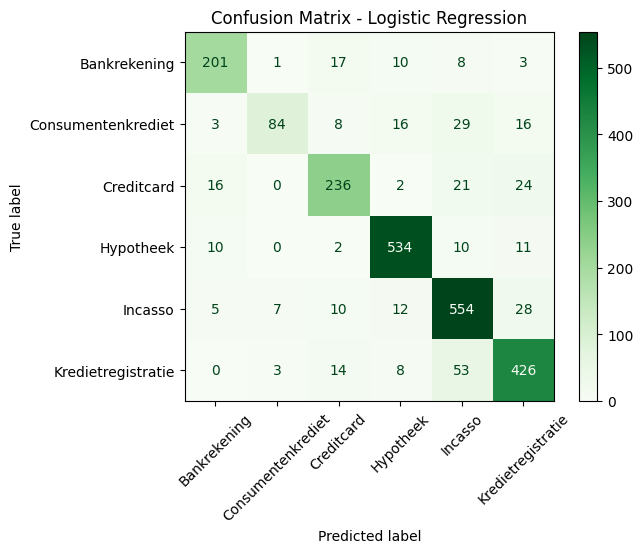

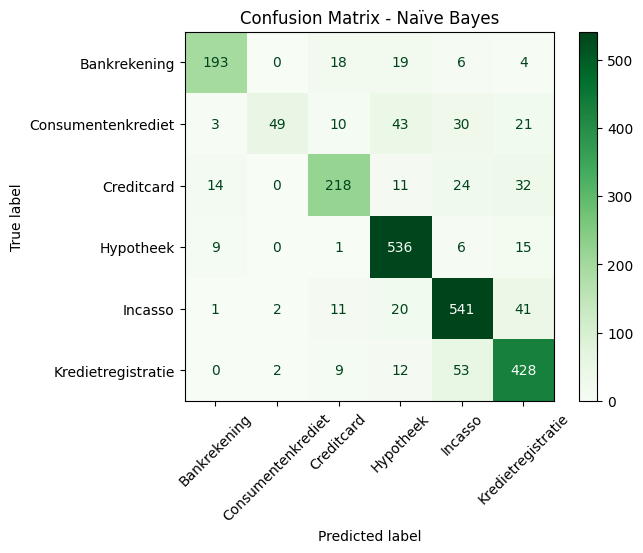

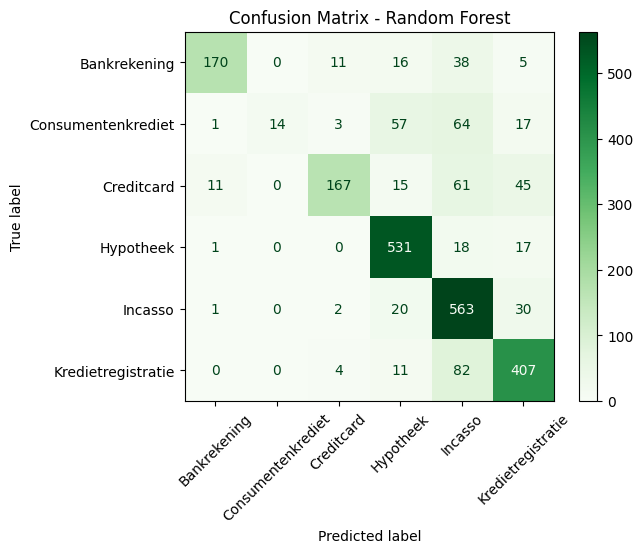

In [55]:
#Confusion matrixes 3 modellen
for name, model in modellen.items():
    y_pred = model.predict(x_test)
    confusion = confusion_matrix(y_test, y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=model.classes_)
    display.plot(cmap="Greens")
    plt.title(f"Confusion Matrix - {name}")
    plt.xticks(rotation=45)
    plt.show()


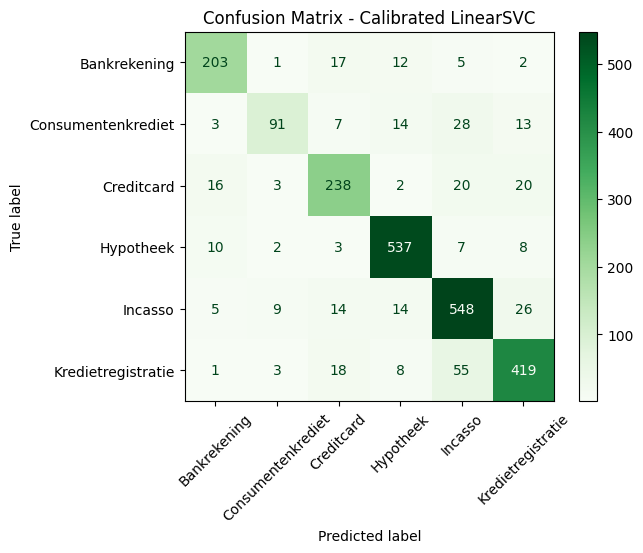

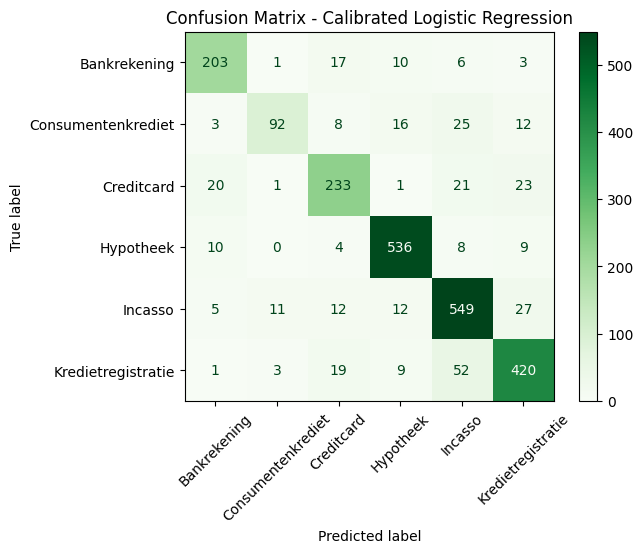

In [56]:
#Confusion matrixes Calibrated

#Calibrated LinearSVC
cm_svc = confusion_matrix(y_test, cal_svc_pred, labels=classes)

disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=classes)
disp_svc.plot(cmap="Greens", xticks_rotation=45)
plt.title("Confusion Matrix - Calibrated LinearSVC")
plt.show()

#Calibrated Logistic Regression
cm_lr = confusion_matrix(y_test, cal_lr_pred, labels=classes)

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=classes)
disp_lr.plot(cmap="Greens", xticks_rotation=45)
plt.title("Confusion Matrix - Calibrated Logistic Regression")
plt.show()